In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os

# Go to project root
os.chdir('C:/Users/HomePC/Documents/kifiya/news-sentiment-analysis')

plt.style.use('ggplot')

# Load data
stock_df = pd.read_csv('data/raw/stock_prices_clean.csv', parse_dates=['Date'])
print(f"Loaded {len(stock_df)} rows")
print(f"Stocks: {stock_df['Symbol'].unique().tolist()}")
print(stock_df.head(3))

Loaded 2510 rows
Stocks: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'TSLA', 'JPM', 'BAC', 'WMT', 'PFE']
        Date       Close        High         Low        Open    Volume Symbol
0 2025-05-15  210.614441  212.118484  208.711985  210.116417  45029500   AAPL
1 2025-05-16  210.425201  211.730038  208.941099  211.520861  54737900   AAPL
2 2025-05-19  207.955017  208.652248  203.452873  207.088460  46140500   AAPL


In [17]:
def sma(data, period):
    return data.rolling(window=period).mean()

def ema(data, period):
    return data.ewm(span=period, adjust=False).mean()

def rsi(data, period=14):
    delta = data.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

def macd(data, fast=12, slow=26, signal=9):
    ema_fast = data.ewm(span=fast, adjust=False).mean()
    ema_slow = data.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram = macd_line - signal_line
    return macd_line, signal_line, histogram

print("✅ Helper functions ready")

✅ Helper functions ready


In [18]:
symbol = 'AAPL'
df = stock_df[stock_df['Symbol'] == symbol].copy()
df = df.sort_values('Date').reset_index(drop=True)

df['SMA_20'] = sma(df['Close'], 20)
df['SMA_50'] = sma(df['Close'], 50)
df['EMA_20'] = ema(df['Close'], 20)
df['RSI'] = rsi(df['Close'], 14)
df['MACD'], df['MACD_Signal'], df['MACD_Hist'] = macd(df['Close'])

print(f"{symbol}: {len(df)} days")
print(df[['Date', 'Close', 'SMA_20', 'RSI']].tail(5))

AAPL: 251 days
          Date       Close      SMA_20        RSI
246 2026-05-08  293.050018  272.960016  72.941202
247 2026-05-11  292.679993  274.645944  72.360729
248 2026-05-12  294.799988  276.456357  73.654347
249 2026-05-13  298.869995  278.090619  75.978793
250 2026-05-14  298.209991  279.843242  74.825876


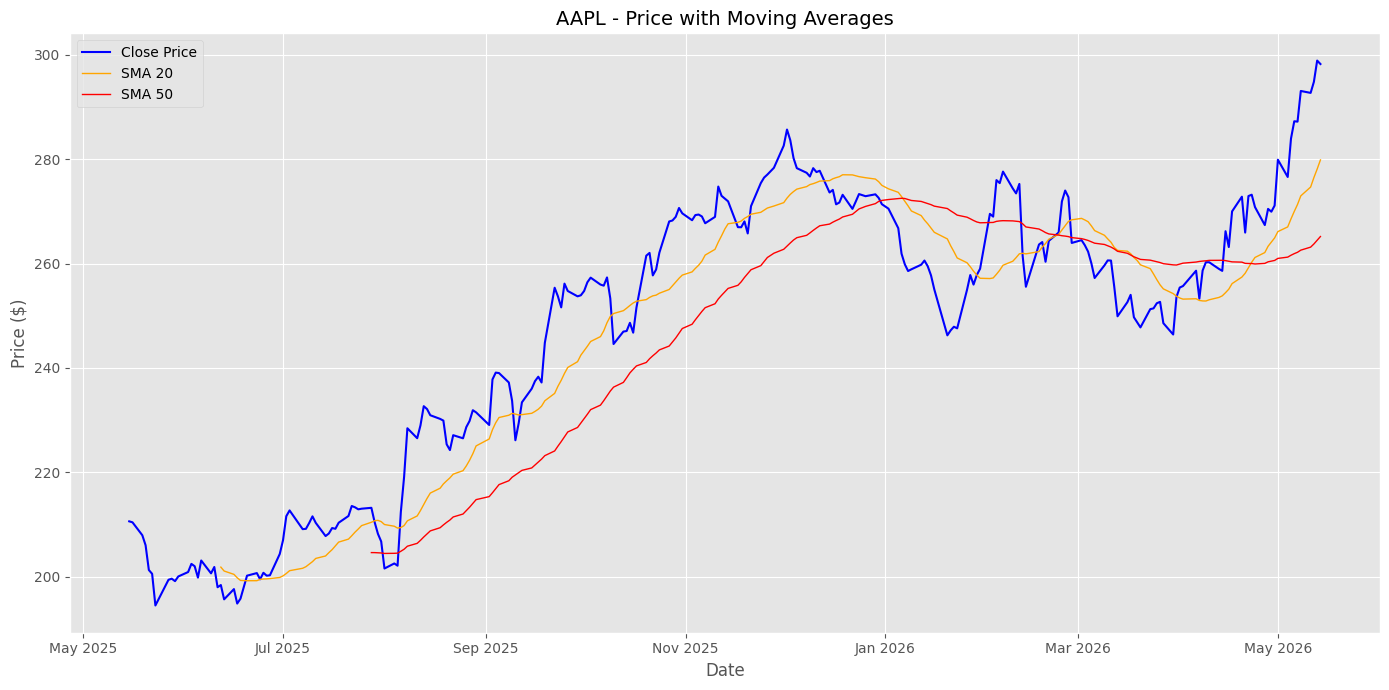

In [19]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(df['Date'], df['Close'], label='Close Price', linewidth=1.5, color='blue')
ax.plot(df['Date'], df['SMA_20'], label='SMA 20', linewidth=1, color='orange')
ax.plot(df['Date'], df['SMA_50'], label='SMA 50', linewidth=1, color='red')

ax.set_title(f'{symbol} - Price with Moving Averages', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Price ($)')
ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()

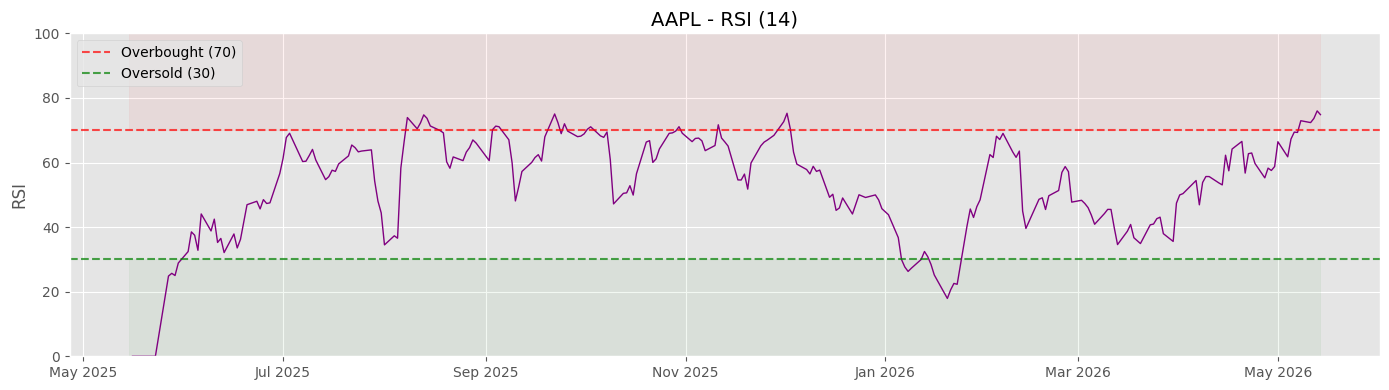

In [20]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df['Date'], df['RSI'], color='purple', linewidth=1)
ax.axhline(70, color='red', linestyle='--', alpha=0.7, label='Overbought (70)')
ax.axhline(30, color='green', linestyle='--', alpha=0.7, label='Oversold (30)')
ax.fill_between(df['Date'], 70, 100, color='red', alpha=0.05)
ax.fill_between(df['Date'], 0, 30, color='green', alpha=0.05)

ax.set_title(f'{symbol} - RSI (14)', fontsize=14)
ax.set_ylabel('RSI')
ax.set_ylim(0, 100)
ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()

In [21]:
latest = df.iloc[-1]
print(f"=== {symbol} - {latest['Date'].date()} ===")
print(f"Close: ${latest['Close']:.2f}")
print(f"SMA 20: ${latest['SMA_20']:.2f} | SMA 50: ${latest['SMA_50']:.2f}")
print(f"RSI: {latest['RSI']:.1f}")
print(f"MACD: {latest['MACD']:.3f} | Signal: {latest['MACD_Signal']:.3f}")

if latest['RSI'] > 70:
    print("RSI: OVERBOUGHT - Sell signal")
elif latest['RSI'] < 30:
    print("RSI: OVERSOLD - Buy signal")
else:
    print("RSI: Neutral")

if latest['SMA_20'] > latest['SMA_50']:
    print("MA: BULLISH (SMA20 > SMA50)")
else:
    print("MA: BEARISH (SMA20 < SMA50)")

=== AAPL - 2026-05-14 ===
Close: $298.21
SMA 20: $279.84 | SMA 50: $265.17
RSI: 74.8
MACD: 9.210 | Signal: 7.297
RSI: OVERBOUGHT - Sell signal
MA: BULLISH (SMA20 > SMA50)


In [22]:
# Volatility (20-day rolling)
df['Daily_Return'] = df['Close'].pct_change() * 100
df['Volatility_20'] = df['Daily_Return'].rolling(20).std()

# Average True Range (ATR) - manual calculation
df['H-L'] = df['High'] - df['Low']
df['H-PC'] = abs(df['High'] - df['Close'].shift(1))
df['L-PC'] = abs(df['Low'] - df['Close'].shift(1))
df['TR'] = df[['H-L', 'H-PC', 'L-PC']].max(axis=1)
df['ATR_14'] = df['TR'].rolling(14).mean()

# Bollinger Bands
df['BB_Mid'] = df['SMA_20']
df['BB_Upper'] = df['BB_Mid'] + 2 * df['Close'].rolling(20).std()
df['BB_Lower'] = df['BB_Mid'] - 2 * df['Close'].rolling(20).std()

print("✅ Additional metrics calculated")
print(df[['Date', 'Close', 'Volatility_20', 'ATR_14', 'BB_Upper', 'BB_Lower']].tail())

✅ Additional metrics calculated
          Date       Close  Volatility_20    ATR_14    BB_Upper    BB_Lower
246 2026-05-08  293.050018       1.659118  6.917198  291.589632  254.330399
247 2026-05-11  292.679993       1.648353  6.631988  294.029156  255.262732
248 2026-05-12  294.799988       1.638423  6.285344  296.284637  256.628077
249 2026-05-13  298.869995       1.560232  6.521330  299.665274  256.515963
250 2026-05-14  298.209991       1.519696  6.606578  301.997346  257.689137


In [23]:
# Calculate key indicators for ALL stocks
summary_data = []

for symbol in stock_df['Symbol'].unique():
    sub = stock_df[stock_df['Symbol'] == symbol].sort_values('Date')
    sub = sub.reset_index(drop=True)
    
    if len(sub) < 50:
        continue
    
    # Latest values
    latest = sub.iloc[-1]
    sma20 = sub['Close'].rolling(20).mean().iloc[-1]
    sma50 = sub['Close'].rolling(50).mean().iloc[-1]
    rsi_val = rsi(sub['Close']).iloc[-1]
    ret_5d = (sub['Close'].iloc[-1] / sub['Close'].iloc[-6] - 1) * 100
    
    summary_data.append({
        'Symbol': symbol,
        'Price': latest['Close'],
        'SMA_20': sma20,
        'SMA_50': sma50,
        'RSI': rsi_val,
        '5D_Return': ret_5d,
        'Signal': 'BUY' if rsi_val < 30 else ('SELL' if rsi_val > 70 else 'HOLD')
    })

summary_df = pd.DataFrame(summary_data)
print("=== Multi-Stock Technical Summary ===")
print(summary_df.to_string(index=False))

=== Multi-Stock Technical Summary ===
Symbol      Price     SMA_20     SMA_50       RSI  5D_Return Signal
  AAPL 298.209991 279.843242 265.167920 74.825876   3.842452   SELL
  MSFT 409.429993 417.448999 398.839999 50.320530  -2.695058   HOLD
 GOOGL 401.070007 370.137001 330.814366 74.163783   0.773893   SELL
  AMZN 267.220001 263.848000 235.804000 62.904046  -1.456655   HOLD
  META 618.429993 638.427499 622.720376 47.091580   0.262641   HOLD
  TSLA 443.299988 400.239001 386.445801 69.023451   7.651953   HOLD
   JPM 299.910004 308.833000 299.568771 43.748919  -2.076594   HOLD
   BAC  49.849998  52.392000  50.528600 38.049830  -5.497633   HOLD
   WMT 132.460007 129.683252 126.193911 60.482195   1.929952   HOLD
   PFE  25.750000  26.186768  26.566484 41.489376  -1.151629   HOLD
